In [1]:
import pandas as pd

df = pd.read_csv("C:/Users/Sambhrama/Downloads/final_aviation_ml_dataset_deduplicated.csv")
print(df.shape)
print(df.head())

print(df['hfacs_label'].value_counts())

(17993, 4)
            ev_id  event_date  \
0  20080107X00026  2008-01-01   
1  20080107X00027  2008-01-03   
2  20080109X00036  2008-01-01   
3  20080114X00044  2008-01-06   
4  20080115X00046  2008-01-03   

                                         report_text   hfacs_label  
0  The pilots were attending a fly-in at the airp...    Unsafe Act  
1  After an uneventful landing at night, the comm...  Precondition  
2  The private pilot was conducting a touch-and-g...  Precondition  
3  According to the certified flight instructor (...    Unsafe Act  
4  While on short final approach the pilot reduce...    Unsafe Act  
Unsafe Act            15358
Precondition           2376
Unsafe Supervision      259
Name: hfacs_label, dtype: int64


In [2]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('omw-1.4')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['report_text'].apply(clean_text)

print(df[['report_text', 'clean_text']].head())


[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Sambhrama\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sambhrama\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Sambhrama\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                         report_text  \
0  The pilots were attending a fly-in at the airp...   
1  After an uneventful landing at night, the comm...   
2  The private pilot was conducting a touch-and-g...   
3  According to the certified flight instructor (...   
4  While on short final approach the pilot reduce...   

                                          clean_text  
0  pilot attending flyin airport one pilot lowwin...  
1  uneventful landing night commercial rated pilo...  
2  private pilot conducting touchandgo tailwheele...  
3  according certified flight instructor cfi depa...  
4  short final approach pilot reduced engine powe...  


In [3]:
print(df.columns)

Index(['ev_id', 'event_date', 'report_text', 'hfacs_label', 'clean_text'], dtype='object')


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=10000,   
    ngram_range=(1, 2),
    max_df=0.9,
    min_df=3,
    sublinear_tf=True
)

# Convert text to numeric features
X = vectorizer.fit_transform(df['clean_text'])

y = df['hfacs_label']

print("TF-IDF feature matrix shape:", X.shape)
print("Target shape:", y.shape)
vectorizer.get_feature_names_out()[:20]

TF-IDF feature matrix shape: (17993, 10000)
Target shape: (17993,)


array(['abeam', 'ability', 'ability safely', 'able', 'able climb',
       'able determine', 'able exit', 'able land', 'able maintain',
       'able reach', 'able recover', 'able regain', 'able see',
       'able stop', 'abnormal', 'abnormality', 'abnormality would',
       'aboard', 'abort', 'abort landing'], dtype=object)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,                # TF-IDF features
    y,                # labels
    test_size=0.2,    
    random_state=42,  
    stratify=y        
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (14394, 10000)
Testing set shape: (3599, 10000)


In [6]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=15,     # K = 5 (standard choice)
    metric='cosine',
    weights='distance'# cosine similarity is best for TF-IDF
)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print(y_pred_knn[:10])

['Unsafe Act' 'Unsafe Act' 'Unsafe Act' 'Unsafe Act' 'Precondition'
 'Unsafe Act' 'Unsafe Act' 'Unsafe Act' 'Unsafe Act' 'Unsafe Act']


In [7]:
y_test.value_counts(normalize=True)

Unsafe Act            0.853570
Precondition          0.131981
Unsafe Supervision    0.014448
Name: hfacs_label, dtype: float64

In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

                    precision    recall  f1-score   support

      Precondition       0.64      0.32      0.43       475
        Unsafe Act       0.89      0.97      0.93      3072
Unsafe Supervision       0.67      0.08      0.14        52

          accuracy                           0.87      3599
         macro avg       0.73      0.46      0.50      3599
      weighted avg       0.85      0.87      0.85      3599



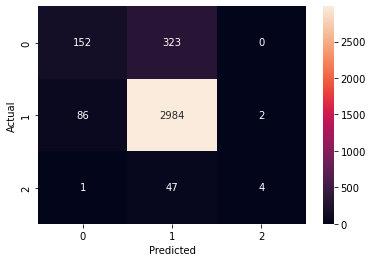

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
y_prob_knn = knn.predict_proba(X_test)

In [11]:
from sklearn.preprocessing import label_binarize

classes = ['Precondition', 'Unsafe Act', 'Unsafe Supervision']

y_test_bin = label_binarize(y_test, classes=classes)


In [12]:
from sklearn.metrics import roc_curve, auc

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_knn[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


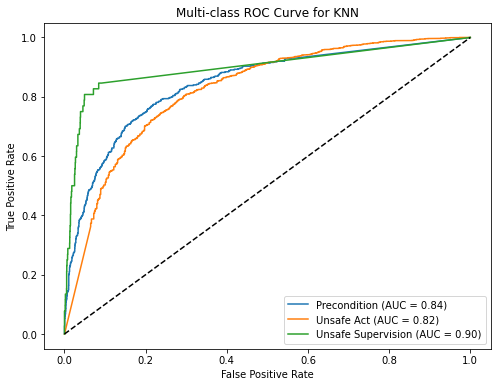

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i, label in enumerate(classes):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')   
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve for KNN")
plt.legend()
plt.show()


In [14]:
#comparing with random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,     
    random_state=42,       
    class_weight='balanced'  
)

In [15]:
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [16]:
y_pred_rf=rf.predict(X_test)

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
                    precision    recall  f1-score   support

      Precondition       0.76      0.22      0.34       475
        Unsafe Act       0.88      0.99      0.93      3072
Unsafe Supervision       1.00      0.02      0.04        52

          accuracy                           0.87      3599
         macro avg       0.88      0.41      0.44      3599
      weighted avg       0.86      0.87      0.84      3599



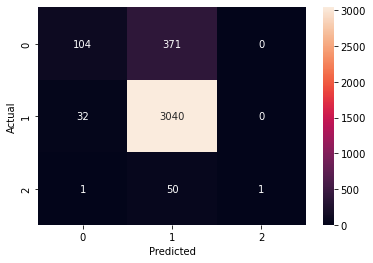

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [19]:
y_prob_rf = rf.predict_proba(X_test)

In [20]:
from sklearn.preprocessing import label_binarize

classes = ['Precondition', 'Unsafe Act', 'Unsafe Supervision']

y_test_bin = label_binarize(y_test, classes=classes)


In [21]:
from sklearn.metrics import roc_curve, auc

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


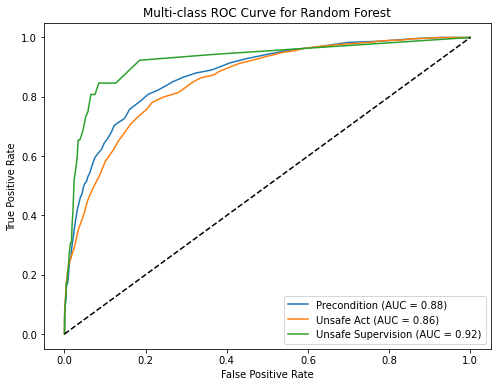

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i, label in enumerate(classes):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve for Random Forest")
plt.legend()
plt.show()


In [22]:
#extra trees
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix


et = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)

print("Extra Trees Classification Report:")
print(classification_report(y_test, y_pred_et))


Extra Trees Classification Report:
                    precision    recall  f1-score   support

      Precondition       0.76      0.28      0.41       475
        Unsafe Act       0.88      0.99      0.93      3072
Unsafe Supervision       1.00      0.02      0.04        52

          accuracy                           0.88      3599
         macro avg       0.88      0.43      0.46      3599
      weighted avg       0.87      0.88      0.85      3599



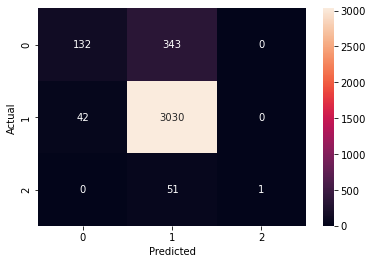

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_et)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [24]:
y_prob_et = et.predict_proba(X_test)

In [25]:
from sklearn.preprocessing import label_binarize

classes = ['Precondition', 'Unsafe Act', 'Unsafe Supervision']

y_test_bin = label_binarize(y_test, classes=classes)


In [26]:
from sklearn.metrics import roc_curve, auc

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_et[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


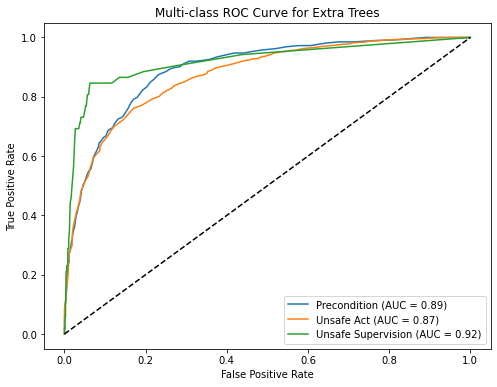

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i, label in enumerate(classes):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve for Extra Trees")
plt.legend()
plt.show()

In [28]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [29]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


In [30]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


In [31]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    colsample_bytree=0.8,
    objective='multi:softmax',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)


In [32]:
xgb.fit(X_train, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, objective='multi:softmax', ...)

In [33]:
y_pred_xgb_enc = xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)


In [34]:
from sklearn.metrics import classification_report, confusion_matrix

print("XGBoost Classification Report:")
print(classification_report(y_test_enc, y_pred_xgb_enc))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.37      0.48       475
           1       0.90      0.97      0.93      3072
           2       0.50      0.04      0.07        52

    accuracy                           0.88      3599
   macro avg       0.69      0.46      0.50      3599
weighted avg       0.86      0.88      0.86      3599



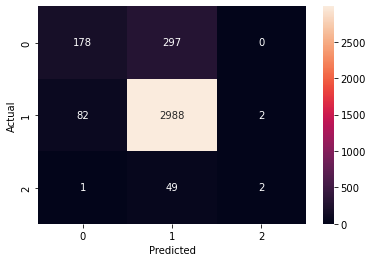

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
y_prob_xgb = xgb.predict_proba(X_test)


In [37]:
from sklearn.preprocessing import label_binarize

classes = le.classes_
y_test_bin = label_binarize(y_test, classes=classes)


In [38]:
from sklearn.metrics import roc_curve, auc

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_xgb[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


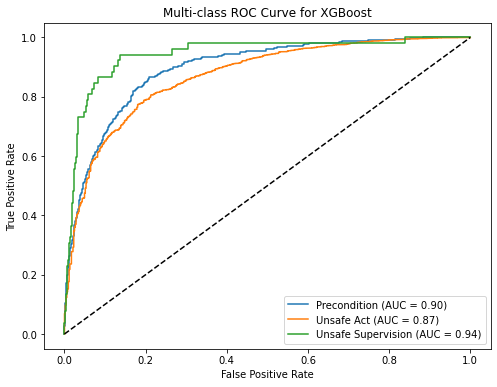

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i, label in enumerate(classes):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve for XGBoost")
plt.legend()
plt.show()


In [57]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report




In [58]:
df = pd.read_csv("C:/Users/Sambhrama/Downloads/final_aviation_ml_dataset_deduplicated.csv")

#df["text"] = (
 #   df["finding_description"].fillna("") + " " +
 #   df["narr_accf"].fillna(""))


In [59]:
#tfidf = TfidfVectorizer(
#    max_features=50000,
"""  
ngram_range=(1,2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

X = tfidf.fit_transform(df["text"])
y = df["label"]
"""
X = df['report_text']
y = df['hfacs_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [60]:

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_df=0.9
    )),
    ("rf", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])



In [61]:

param_grid = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    
    "rf__n_estimators": [200, 300],
    "rf__max_depth": [None, 20, 40],
    "rf__min_samples_split": [2, 5]
}


In [62]:
#rf = RandomForestClassifier(
#    random_state=42,
#    n_jobs=-1,
#    class_weight="balanced"
#)
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)



Fitting 3 folds for each of 48 candidates, totalling 144 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_df=0.9,
                                                        stop_words='english')),
                                       ('rf',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [None, 20, 40],
                         'rf__min_samples_split': [2, 5],
                         'rf__n_estimators': [200, 300],
                         'tfidf__max_features': [3000, 5000],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='accuracy', verbose=2)

In [63]:
print("Best Parameters:")
print(grid.best_params_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Best Parameters:
{'rf__max_depth': 40, 'rf__min_samples_split': 5, 'rf__n_estimators': 300, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 2)}
Accuracy: 0.8824673520422339
                    precision    recall  f1-score   support

      Precondition       0.71      0.36      0.48       475
        Unsafe Act       0.90      0.98      0.93      3072
Unsafe Supervision       1.00      0.02      0.04        52

          accuracy                           0.88      3599
         macro avg       0.87      0.45      0.48      3599
      weighted avg       0.87      0.88      0.86      3599



In [27]:

!pip install scikit-optimize


In [28]:
from skopt import BayesSearchCV
from sklearn.ensemble import RandomForestClassifier

search_space = {
    'n_estimators': (100, 500),
    'max_depth': (10, 50),
    'min_samples_split': (2, 10),
    'min_samples_leaf': (1, 5)
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

bayes_search = BayesSearchCV(
    estimator=rf,
    search_spaces=search_space,
    n_iter=30,          
    cv=5,
    scoring='accuracy',
    random_state=42
)

bayes_search.fit(X_train, y_train)

print(bayes_search.best_params_)
print(bayes_search.best_score_)



OrderedDict([('max_depth', 50), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])
0.8771708866366182


In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load final dataset
df = pd.read_csv("C:/Users/Sambhrama/Downloads/final_aviation_ml_dataset_deduplicated.csv")

# Split
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['hfacs_label']
)

# Create summary table
summary = []

classes = df['hfacs_label'].unique()

for c in classes:
    total = df[df['hfacs_label'] == c].shape[0]
    train = train_df[train_df['hfacs_label'] == c].shape[0]
    test = test_df[test_df['hfacs_label'] == c].shape[0]
    
    summary.append([c, total, train, test])

summary_df = pd.DataFrame(summary, columns=[
    "HFACS Category", "Total Samples", "Train Samples", "Test Samples"
])

# Add totals
total_row = pd.DataFrame([[
    "Total",
    summary_df["Total Samples"].sum(),
    summary_df["Train Samples"].sum(),
    summary_df["Test Samples"].sum()
]], columns=summary_df.columns)

summary_df = pd.concat([summary_df, total_row])

summary_df


,HFACS Category,Total Samples,Train Samples,Test Samples
0,Unsafe Act,15358,12286,3072
1,Precondition,2376,1901,475
2,Unsafe Supervision,259,207,52
0,Total,17993,14394,3599
